# Notebook 2 — Experiment 1, Step 2: Epoch Sweep at Fixed Learning Rate

**Decision from Step 1:** LR = `1e-3` had the lowest validation loss (4.94 at epoch 10) and was still descending. Lower LRs (1e-4, 5e-4) overfit fast and val loss started climbing; 1e-2 diverged.

**Step 2 strategy — single long run, not separate runs.**
Training one model for 100 epochs and logging loss per epoch is *strictly more informative* than training separate 5/10/20/50/100-epoch models: the curves from the long run contain all the truncated-run answers as slices.

**What this notebook does:**
1. Reuses every setup cell from Step 1 (data, tokenizer, model, training utils)
2. Defines a new `train_with_epoch_logging` that does **one full-val-set eval per epoch** instead of the noisy `eval_iter=1` from Step 1 — this gives clean publication-quality curves
3. Trains at LR=1e-3 for up to 100 epochs with **early stopping** (stop if val loss hasn't beaten its best in 15 epochs)
4. Saves checkpoints at epochs {5, 10, 20, 50, 100} **and** at the best-val epoch — the saved best is what NB3/NB4/NB5 will compare against
5. Plots train+val curves, the train/val gap (overfitting onset), and a table of losses at the assignment's reference epoch counts

**Estimated runtime on A100:** ~60 min for 100 epochs. If val is still descending at epoch 100, a follow-up cell extends to 200.


In [1]:
# ── Device setup (GPU) ──────────────────────────────────────────────
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", device)
if device.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))


PyTorch: 2.4.1+cu124
Device : cuda
GPU    : NVIDIA GeForce RTX 4090


### STEP 1: LOADING THE DATASET


In [2]:
import os

file_path = "A History of Indian Philosophy Volume 1.txt"

# Check if the file exists in the current directory (i.e., Colab session)
if os.path.exists(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        raw_text = file.read()
    print(f"File '{file_path}' loaded with {len(raw_text)} characters.")
else:
    print(f"File '{file_path}' not found. Please upload it to the Colab environment first.")


File 'A History of Indian Philosophy Volume 1.txt' loaded with 1342083 characters.


### STEP 2: IMPLEMENTING THE TOKENIZER


In [3]:
!pip3 install tiktoken > /dev/null 2>&1

In [4]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.12.0


In [5]:
tokenizer = tiktoken.get_encoding("gpt2")

In [6]:
total_characters = len(raw_text)
total_tokens = len(tokenizer.encode(raw_text))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 1342083
Tokens: 357340


### STEP 3: CREATING INPUT-TARGET PAIRS

In [7]:
with open("A History of Indian Philosophy Volume 1.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

357340


In [8]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [9]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [10]:
import torch
print("PyTorch version:", torch.__version__)
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

PyTorch version: 2.4.1+cu124
[tensor([[  464,  4935, 20336, 46566]]), tensor([[ 4935, 20336, 46566,   286]])]


### STEP 4: IMPLEMENTING MULTI-HEAD ATTENTION

In [11]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

### STEP 5: IMPLEMENTING A GPT MODEL FROM SCRATCH TO GENERATE TEXT

In [12]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

### STEP 6: THE BUILDING BLOCKS-LAYER NORMALIZATION, GELU AND FEED-FORWARD NEURAL NETWORK

In [13]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), ## Expansion
            GELU(), ## Activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), ## Contraction
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        # 2*4*768
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x
        # 2*4*768

### STEP 7: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION

In [15]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

### STEP 8: GENERATING TEXT FROM OUTPUT TOKENS

In [16]:
def generate_text_simple(model, idx, max_new_tokens, context_size):

    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond) ### batch, n_tokens, vocab_size

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [17]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())

### STEP 9: CREATING TRAINING, TESTING AND VALIDATION DATA

In [18]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

### STEP 10: DEFINING THE CROSS ENTROPY LOSS FUNCTION

In [19]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GPTModel(GPT_CONFIG_124M)
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.983911429511176
Validation loss: 10.988269606632972


In [21]:
print(device)

cuda


### STEP 11: TRAINING LOOP FOR THE LLM

In [22]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [23]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [24]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [25]:
!pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

In [29]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

## EXPERIMENT 1 — Phase 2: Long run at LR=1e-3 with per-epoch logging

All cells from here on are new for Step 2. Everything above is identical to Step 1 (data loading, model definition, helper functions).

In [30]:
import os, json, time, math
import torch
import matplotlib.pyplot as plt

# Phase 2 hyperparameters
PHASE2_LR              = 1e-3
PHASE2_MAX_EPOCHS      = 100         # extend later if val still improving
PHASE2_PATIENCE        = 15          # early-stop if no val improvement in N epochs
PHASE2_CKPT_EPOCHS     = [5, 10, 20, 50, 100]   # save checkpoints at these epochs
PHASE2_CKPT_DIR        = 'phase2_checkpoints'
PHASE2_RESULTS_FILE    = 'phase2_results.json'

os.makedirs(PHASE2_CKPT_DIR, exist_ok=True)
print(f'Will train for up to {PHASE2_MAX_EPOCHS} epochs at lr={PHASE2_LR}')
print(f'Checkpoints saved to: {PHASE2_CKPT_DIR}/')
print(f'Early stopping patience: {PHASE2_PATIENCE} epochs')


Will train for up to 100 epochs at lr=0.001
Checkpoints saved to: phase2_checkpoints/
Early stopping patience: 15 epochs


### Per-epoch training loop

Differences from Step 1's `train_model_simple`:
- Returns **epoch-level** losses, not step-level
- Evaluates on **full val set** each epoch (`eval_iter=None`)
- Tracks best val loss + early-stops if no improvement
- Saves checkpoints at user-specified epochs

In [31]:
def train_with_epoch_logging(
    model, train_loader, val_loader, optimizer, device,
    max_epochs, patience, ckpt_epochs, ckpt_dir, config,
):
    """Train and log train/val loss once per epoch on the full val set.

    Returns dict with per-epoch losses, best-val info, and where checkpoints landed.
    """
    train_losses_per_epoch = []
    val_losses_per_epoch   = []
    epoch_times            = []
    best_val_loss          = float('inf')
    best_val_epoch         = -1
    epochs_since_best      = 0
    saved_checkpoints      = {}   # epoch -> filepath

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()

        # ---- Train one full epoch ----
        model.train()
        running_loss, n_batches = 0.0, 0
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1
        train_loss = running_loss / max(n_batches, 1)

        # ---- Eval on full val set ----
        model.eval()
        with torch.no_grad():
            val_loss = calc_loss_loader(val_loader, model, device)  # num_batches=None => full set

        dt = time.time() - t0
        train_losses_per_epoch.append(train_loss)
        val_losses_per_epoch.append(val_loss)
        epoch_times.append(dt)

        # ---- Track best val + early-stop counter ----
        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_val_epoch = epoch
            epochs_since_best = 0
            # Save 'best' checkpoint (overwrite previous best)
            best_path = os.path.join(ckpt_dir, 'best.pt')
            torch.save({
                'epoch': epoch,
                'val_loss': val_loss,
                'config': config,
                'model_state': model.state_dict(),
            }, best_path)
        else:
            epochs_since_best += 1

        # ---- Save scheduled epoch checkpoint ----
        if epoch in ckpt_epochs:
            ckpt_path = os.path.join(ckpt_dir, f'epoch_{epoch:03d}.pt')
            torch.save({
                'epoch': epoch,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'config': config,
                'model_state': model.state_dict(),
            }, ckpt_path)
            saved_checkpoints[epoch] = ckpt_path

        marker = ' ★' if improved else ('  ' if epochs_since_best < patience else ' (stale)')
        print(f'  Epoch {epoch:3d}/{max_epochs} | '
              f'train {train_loss:.4f} | val {val_loss:.4f} | '
              f'best {best_val_loss:.4f} @ ep{best_val_epoch} | '
              f'{dt:.1f}s{marker}')

        # ---- Early stopping ----
        if epochs_since_best >= patience:
            print(f'\n  Early stop: val loss has not improved in {patience} epochs.')
            break

    return {
        'train_losses':       train_losses_per_epoch,
        'val_losses':         val_losses_per_epoch,
        'epoch_times':        epoch_times,
        'best_val_loss':      best_val_loss,
        'best_val_epoch':     best_val_epoch,
        'last_epoch':         len(train_losses_per_epoch),
        'saved_checkpoints':  saved_checkpoints,
    }


### Run training

Fresh model, AdamW, weight_decay=0.1 (matches Step 1 setup). The ★ marker in the log means this epoch achieved a new best val loss.

In [32]:
torch.manual_seed(123)
model_p2 = GPTModel(GPT_CONFIG_124M).to(device)
optimizer_p2 = torch.optim.AdamW(
    model_p2.parameters(), lr=PHASE2_LR, weight_decay=0.1
)

n_params = sum(p.numel() for p in model_p2.parameters())
print(f'Model params: {n_params:,}')
print(f'Train batches/epoch: {len(train_loader)} | Val batches/epoch: {len(val_loader)}')
print()

t0 = time.time()
phase2 = train_with_epoch_logging(
    model=model_p2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_p2,
    device=device,
    max_epochs=PHASE2_MAX_EPOCHS,
    patience=PHASE2_PATIENCE,
    ckpt_epochs=PHASE2_CKPT_EPOCHS,
    ckpt_dir=PHASE2_CKPT_DIR,
    config=GPT_CONFIG_124M,
)
elapsed_min = (time.time() - t0) / 60
print(f'\n✅ Phase 2 done in {elapsed_min:.1f} min')
print(f'Best val loss: {phase2["best_val_loss"]:.4f} at epoch {phase2["best_val_epoch"]}')
print(f'Stopped at epoch {phase2["last_epoch"]} '
      f'(of {PHASE2_MAX_EPOCHS} max)')

# Save full results to JSON for the writeup / NB3-5
results_to_save = {
    **{k: v for k, v in phase2.items() if k != 'saved_checkpoints'},
    'saved_checkpoints': phase2['saved_checkpoints'],
    'lr':                PHASE2_LR,
    'max_epochs':        PHASE2_MAX_EPOCHS,
    'patience':          PHASE2_PATIENCE,
    'config':            GPT_CONFIG_124M,
}
with open(PHASE2_RESULTS_FILE, 'w') as f:
    json.dump(results_to_save, f, indent=2)
print(f'Saved results to {PHASE2_RESULTS_FILE}')


Model params: 162,419,712
Train batches/epoch: 630 | Val batches/epoch: 67

  Epoch   1/100 | train 5.9514 | val 5.6111 | best 5.6111 @ ep1 | 27.9s ★
  Epoch   2/100 | train 5.1119 | val 5.3538 | best 5.3538 @ ep2 | 28.9s ★
  Epoch   3/100 | train 4.8648 | val 5.2935 | best 5.2935 @ ep3 | 28.7s ★
  Epoch   4/100 | train 4.7455 | val 5.2428 | best 5.2428 @ ep4 | 28.8s ★
  Epoch   5/100 | train 4.6466 | val 5.1936 | best 5.1936 @ ep5 | 28.6s ★
  Epoch   6/100 | train 4.5170 | val 5.2101 | best 5.1936 @ ep5 | 28.9s  
  Epoch   7/100 | train 4.4711 | val 5.1680 | best 5.1680 @ ep7 | 28.6s ★
  Epoch   8/100 | train 4.3758 | val 5.1584 | best 5.1584 @ ep8 | 28.9s ★
  Epoch   9/100 | train 4.2616 | val 5.1252 | best 5.1252 @ ep9 | 28.6s ★
  Epoch  10/100 | train 4.0963 | val 5.1246 | best 5.1246 @ ep10 | 28.8s ★
  Epoch  11/100 | train 3.9521 | val 5.1375 | best 5.1246 @ ep10 | 28.8s  
  Epoch  12/100 | train 3.8101 | val 5.1617 | best 5.1246 @ ep10 | 29.0s  
  Epoch  13/100 | train 3.6703 | 

### Decision: extend to 200 epochs?

Rule: if best val loss is at the last epoch (or within the last 5), val is still improving and we should extend. If best val was reached >20 epochs ago, the model has plateaued or overfit and 100 epochs is enough.

In [33]:
last = phase2['last_epoch']
best = phase2['best_val_epoch']
stopped_early = last < PHASE2_MAX_EPOCHS

if stopped_early:
    print(f'Stopped early at epoch {last}. Best val was at epoch {best}.')
    print('→ NO extension needed. Val loss has plateaued.')
elif best >= last - 5:
    print(f'Best val loss was at epoch {best} (last epoch was {last}).')
    print('→ RECOMMEND EXTENDING to 200 epochs — val loss still improving.')
    print('   Run the next cell to continue training.')
else:
    gap = last - best
    print(f'Best val loss was at epoch {best}, ran to {last} ({gap} epochs ago).')
    print('→ NO extension needed. Val loss is no longer improving.')


Stopped early at epoch 25. Best val was at epoch 10.
→ NO extension needed. Val loss has plateaued.


**Optional extension cell.** Only run this if the previous cell said "RECOMMEND EXTENDING". This continues training from epoch 100 to epoch 200, appending to the existing loss history.

In [34]:
# === OPTIONAL: Extend to 200 epochs ===
# Only run if the recommendation above said to extend.
EXTEND_TO_EPOCHS = 200

if phase2['last_epoch'] < PHASE2_MAX_EPOCHS:
    print('Skipping: training stopped early, no extension needed.')
else:
    additional = EXTEND_TO_EPOCHS - PHASE2_MAX_EPOCHS
    print(f'Extending by {additional} more epochs (to epoch {EXTEND_TO_EPOCHS})...')
    extra = train_with_epoch_logging(
        model=model_p2,           # continues from current state
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer_p2,   # continues with same optimizer state
        device=device,
        max_epochs=additional,
        patience=PHASE2_PATIENCE,
        ckpt_epochs=[200 - PHASE2_MAX_EPOCHS],   # save final ckpt at relative epoch 100 -> absolute 200
        ckpt_dir=PHASE2_CKPT_DIR,
        config=GPT_CONFIG_124M,
    )
    # Stitch together
    phase2['train_losses'] += extra['train_losses']
    phase2['val_losses']   += extra['val_losses']
    phase2['epoch_times']  += extra['epoch_times']
    if extra['best_val_loss'] < phase2['best_val_loss']:
        phase2['best_val_loss']  = extra['best_val_loss']
        phase2['best_val_epoch'] = PHASE2_MAX_EPOCHS + extra['best_val_epoch']
    phase2['last_epoch'] = PHASE2_MAX_EPOCHS + extra['last_epoch']
    print(f'\n✅ Extended phase 2 done. Best val: {phase2["best_val_loss"]:.4f} at epoch {phase2["best_val_epoch"]}')

    # Re-save updated results
    results_to_save = {**{k: v for k, v in phase2.items() if k != 'saved_checkpoints'},
                       'saved_checkpoints': phase2['saved_checkpoints'],
                       'lr': PHASE2_LR, 'max_epochs': EXTEND_TO_EPOCHS,
                       'patience': PHASE2_PATIENCE, 'config': GPT_CONFIG_124M}
    with open(PHASE2_RESULTS_FILE, 'w') as f:
        json.dump(results_to_save, f, indent=2)


Skipping: training stopped early, no extension needed.


### Analysis plots

Three figures:
1. **Train + val loss vs. epoch** — main figure for the writeup
2. **Train/val gap vs. epoch** — visualizes when overfitting starts to dominate
3. **Reference-epoch table** — answers the assignment's literal question ("compare epochs 5, 10, 20, 50, 100")

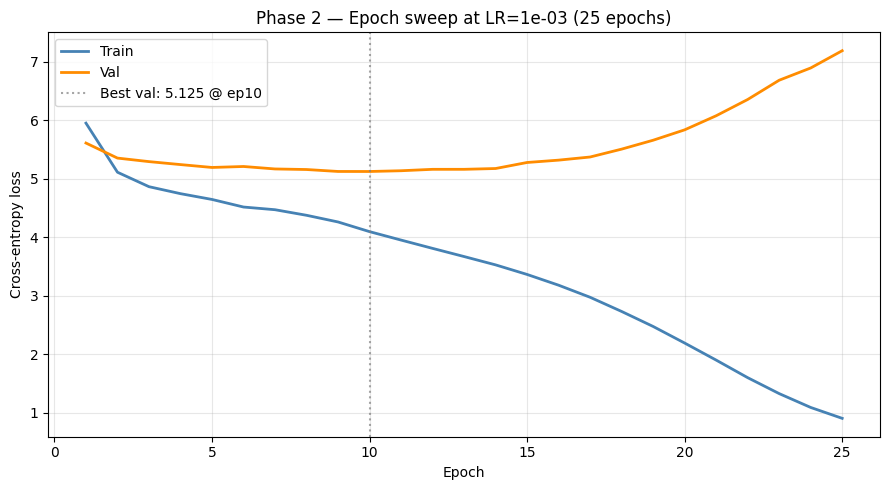

In [35]:
tr = phase2['train_losses']
vl = phase2['val_losses']
epochs = list(range(1, len(tr) + 1))
best_ep = phase2['best_val_epoch']
best_vl = phase2['best_val_loss']

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, tr, color='steelblue', linewidth=2, label='Train')
ax.plot(epochs, vl, color='darkorange', linewidth=2, label='Val')
ax.axvline(best_ep, color='gray', linestyle=':', alpha=0.7,
           label=f'Best val: {best_vl:.3f} @ ep{best_ep}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title(f'Phase 2 — Epoch sweep at LR={PHASE2_LR:.0e} '
             f'({len(epochs)} epochs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase2_loss_curves.pdf')
plt.savefig('phase2_loss_curves.png', dpi=150)
plt.show()


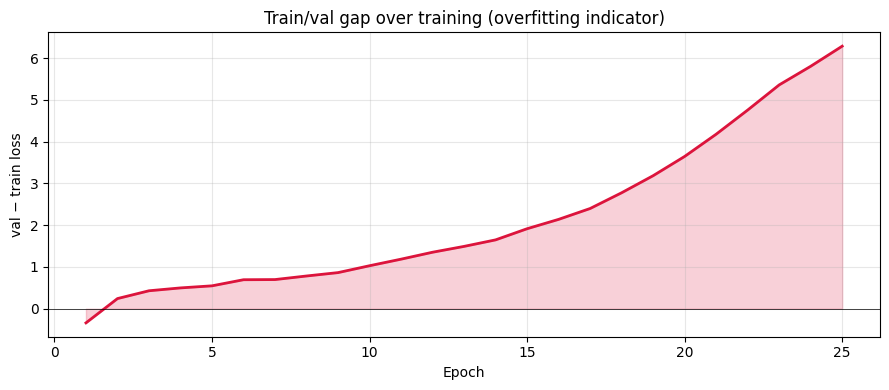

In [36]:
# Train/val gap — visualizes overfitting onset
gap = [v - t for t, v in zip(tr, vl)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, gap, color='crimson', linewidth=2)
ax.fill_between(epochs, 0, gap, alpha=0.2, color='crimson')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('val − train loss')
ax.set_title('Train/val gap over training (overfitting indicator)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase2_overfitting_gap.pdf')
plt.savefig('phase2_overfitting_gap.png', dpi=150)
plt.show()


In [37]:
# Reference-epoch table: snapshot of train/val loss at the assignment's epoch counts
REF_EPOCHS = [5, 10, 20, 50, 100, 200]
print(f"{'Epoch':>6} | {'Train':>8} | {'Val':>8} | {'Gap':>8} | Note")
print('-' * 60)
for e in REF_EPOCHS:
    if e <= len(tr):
        t, v = tr[e-1], vl[e-1]
        note = '★ best' if e == best_ep else ''
        print(f'{e:>6d} | {t:>8.4f} | {v:>8.4f} | {v-t:>+8.4f} | {note}')
    else:
        print(f'{e:>6d} | (not reached — training ended at epoch {len(tr)})')

print(f'\nBest val overall: {best_vl:.4f} at epoch {best_ep}')


 Epoch |    Train |      Val |      Gap | Note
------------------------------------------------------------
     5 |   4.6466 |   5.1936 |  +0.5470 | 
    10 |   4.0963 |   5.1246 |  +1.0283 | ★ best
    20 |   2.1914 |   5.8367 |  +3.6453 | 
    50 | (not reached — training ended at epoch 25)
   100 | (not reached — training ended at epoch 25)
   200 | (not reached — training ended at epoch 25)

Best val overall: 5.1246 at epoch 10


### Generation samples from each checkpoint

Loads each saved checkpoint and generates a sample from the same prompt. Useful for the writeup — shows qualitatively how text quality evolves with training duration. (The val loss numbers say the same thing quantitatively.)

In [38]:
PROMPT = 'There are four collections or Sa@mhitâs'
MAX_NEW_TOKENS = 50

ckpts_to_show = sorted(phase2['saved_checkpoints'].items())
ckpts_to_show.append(('best', os.path.join(PHASE2_CKPT_DIR, 'best.pt')))

for tag, path in ckpts_to_show:
    if not os.path.exists(path):
        print(f'\n[{tag}] checkpoint missing — skipping')
        continue
    ckpt = torch.load(path, map_location=device, weights_only=False)
    m = GPTModel(ckpt['config']).to(device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    ids = text_to_token_ids(PROMPT, tokenizer).to(device)
    with torch.no_grad():
        out = generate(
            model=m, idx=ids,
            max_new_tokens=MAX_NEW_TOKENS,
            context_size=ckpt['config']['context_length'],
            top_k=25, temperature=1.4,
        )
    text = token_ids_to_text(out, tokenizer)
    val = ckpt.get('val_loss', '?')
    epoch = ckpt.get('epoch', '?')
    val_s = f'{val:.4f}' if isinstance(val, float) else val
    print(f'\n=== {tag} (epoch {epoch}, val_loss {val_s}) ===')
    print(text)
    del m
    if device.type == 'cuda':
        torch.cuda.empty_cache()



=== 5 (epoch 5, val_loss 5.1936) ===
There are four collections or Sa@mhitâs_, the cause by the right of this was the mind was thus
for it is regarded as we thus from it was called "there are only.
that we only, he are no
and a cause by the

appearance is

=== 10 (epoch 10, val_loss 5.1246) ===
There are four collections or Sa@mhitâsads (_sasiddhana_. They the
(_vayâra_); it is not so transformed only only as the jug it. But at a person in association with the mind
(_latures of
_tikalaya

=== 20 (epoch 20, val_loss 5.8367) ===
There are four collections or Sa@mhitâsava_. They think that
there is universally differ contrary (_anasa-nhva_) of sense-permanent sense generated by the activity (_d@nu_). The other names the
out (_âgnliness "it is thus

=== best (epoch 10, val_loss 5.1246) ===
There are four collections or Sa@mhitâsûyamañapta (notakas) who know the senses. The _Dattva dravya_ and in the mahas_ which we had
that they
tîta-85, by which all its own _


### Handoff to NB3 / NB4 / NB5

When you spin up the next notebook (Layers / Heads / Ablations), the relevant files in `/workspace/` are:
- `phase2_results.json` — full per-epoch losses, best-val info, config used
- `phase2_checkpoints/best.pt` — best Phase-2 model weights (full 124M baseline to compare GPT-mini variants against)
- `phase2_loss_curves.pdf` / `.png` — main writeup figure

**Download these before terminating the pod**, e.g.:
```bash
cd /workspace && tar czf step2_results.tar.gz \
    Notebook2_Step2.ipynb \
    phase2_results.json \
    phase2_checkpoints/ \
    phase2_loss_curves.pdf phase2_loss_curves.png \
    phase2_overfitting_gap.pdf phase2_overfitting_gap.png
```
